# SHAP 可解释性分析与业务策略输出

本 Notebook 展示 SHAP 关键特征、风险分层结果和高风险客户统计，并将特征重要性映射为可执行策略。

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display, Markdown

def find_project_root():
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / 'config.yaml').exists() and (p / 'outputs').exists():
            return p
    return cwd

project_root = find_project_root()
metrics_dir = project_root / 'outputs' / 'metrics'
fig_dir = project_root / 'outputs' / 'figures'
pred_dir = project_root / 'outputs' / 'predictions'
strategy_path = project_root / 'outputs' / 'strategy' / 'retention_strategy.md'

shap_df = pd.read_csv(metrics_dir / 'shap_feature_importance.csv')
risk_df = pd.read_csv(metrics_dir / 'risk_segment_summary.csv')
high_risk_df = pd.read_csv(pred_dir / 'high_risk_customers.csv')
strategy_text = strategy_path.read_text(encoding='utf-8')

print('project_root =', project_root)
print('shap_df shape =', shap_df.shape, 'risk_df shape =', risk_df.shape, 'high_risk_df shape =', high_risk_df.shape)

project_root = E:\TelecomCustomer_ChurnPrediction
shap_df shape = (36, 2) risk_df shape = (3, 4) high_risk_df shape = (326, 4)


## SHAP Top 10 ??

In [2]:
display(shap_df.head(10))

,feature,mean_abs_shap
0,is_month_to_month,0.586672
1,tenure,0.398143
2,InternetService_Fiber optic,0.257881
3,Contract_Two year,0.248739
4,TotalCharges,0.234928
5,avg_monthly_charge,0.203998
6,PaymentMethod_Electronic check,0.190819
7,MonthlyCharges,0.190701
8,PaperlessBilling_Yes,0.134738
9,OnlineSecurity_Yes,0.122061


## SHAP Summary ?

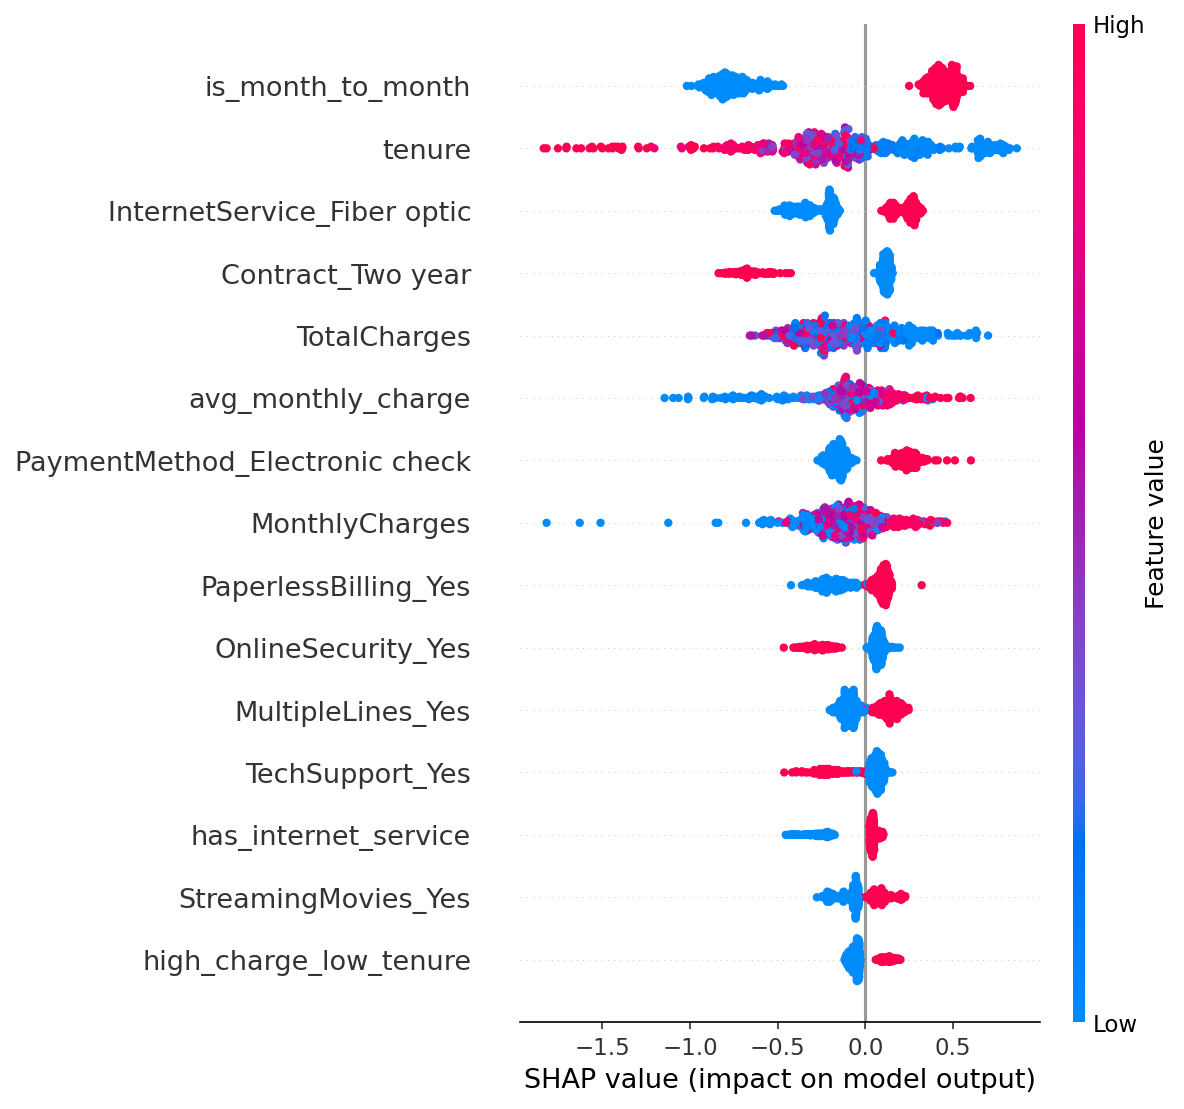

In [3]:
display(Image(filename=str(fig_dir / 'shap_summary.png')))

## SHAP Bar ?

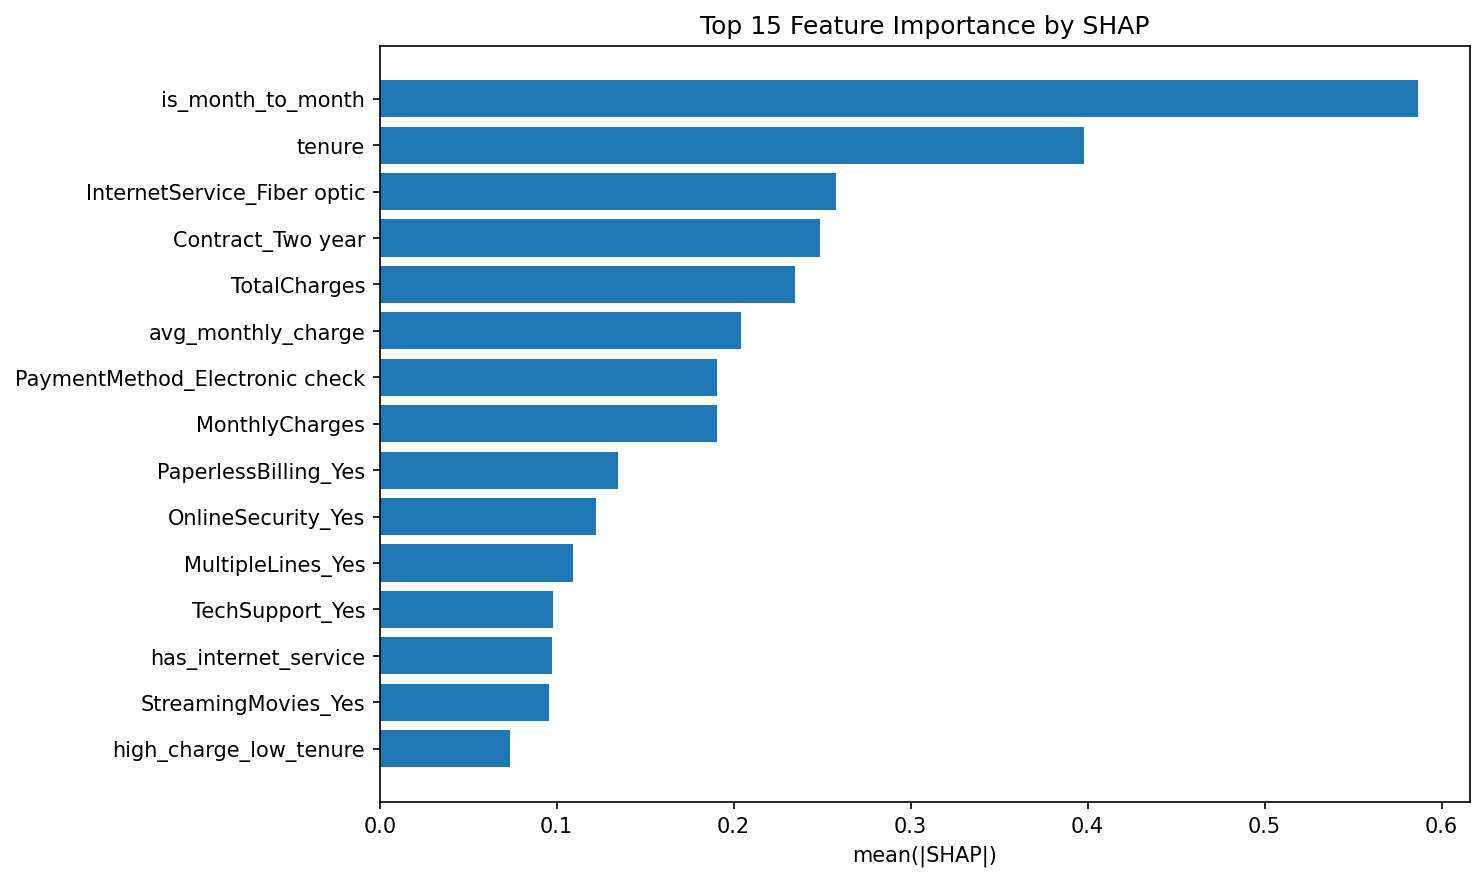

In [4]:
display(Image(filename=str(fig_dir / 'shap_bar.png')))

## SHAP Dependence Top1

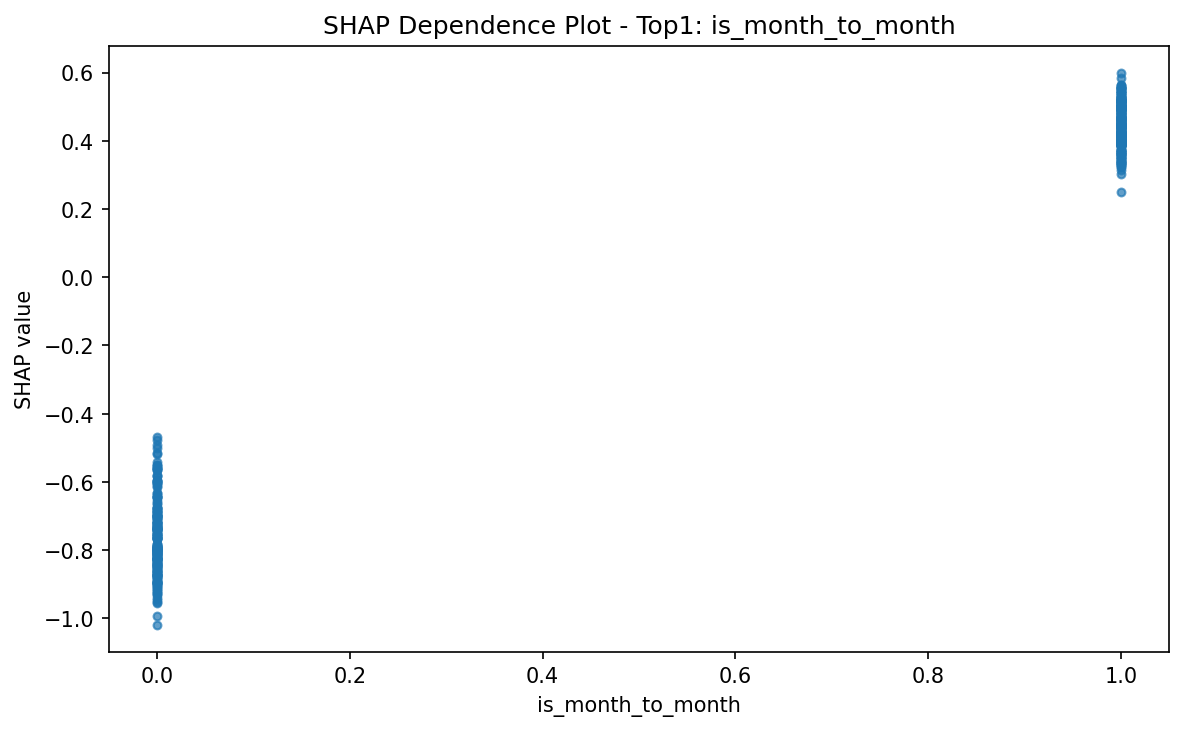

In [5]:
display(Image(filename=str(fig_dir / 'shap_dependence_top1.png')))

## SHAP Dependence Top2

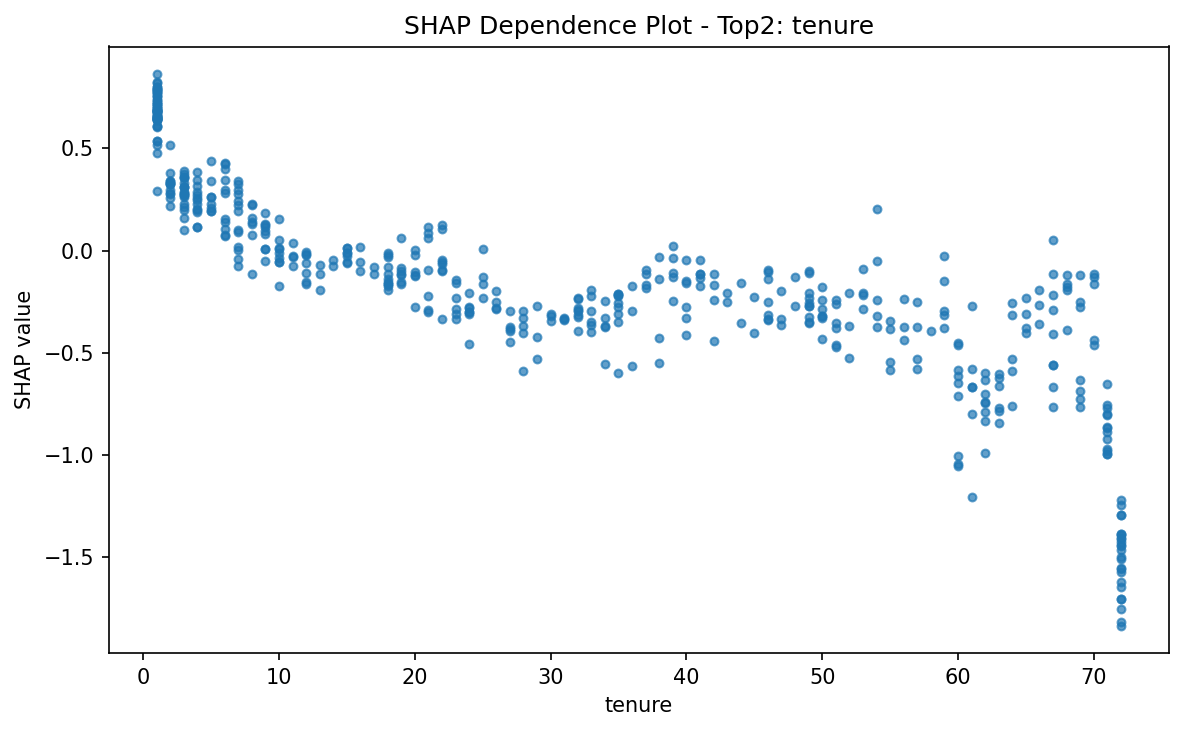

In [6]:
display(Image(filename=str(fig_dir / 'shap_dependence_top2.png')))

## SHAP 本地解释图

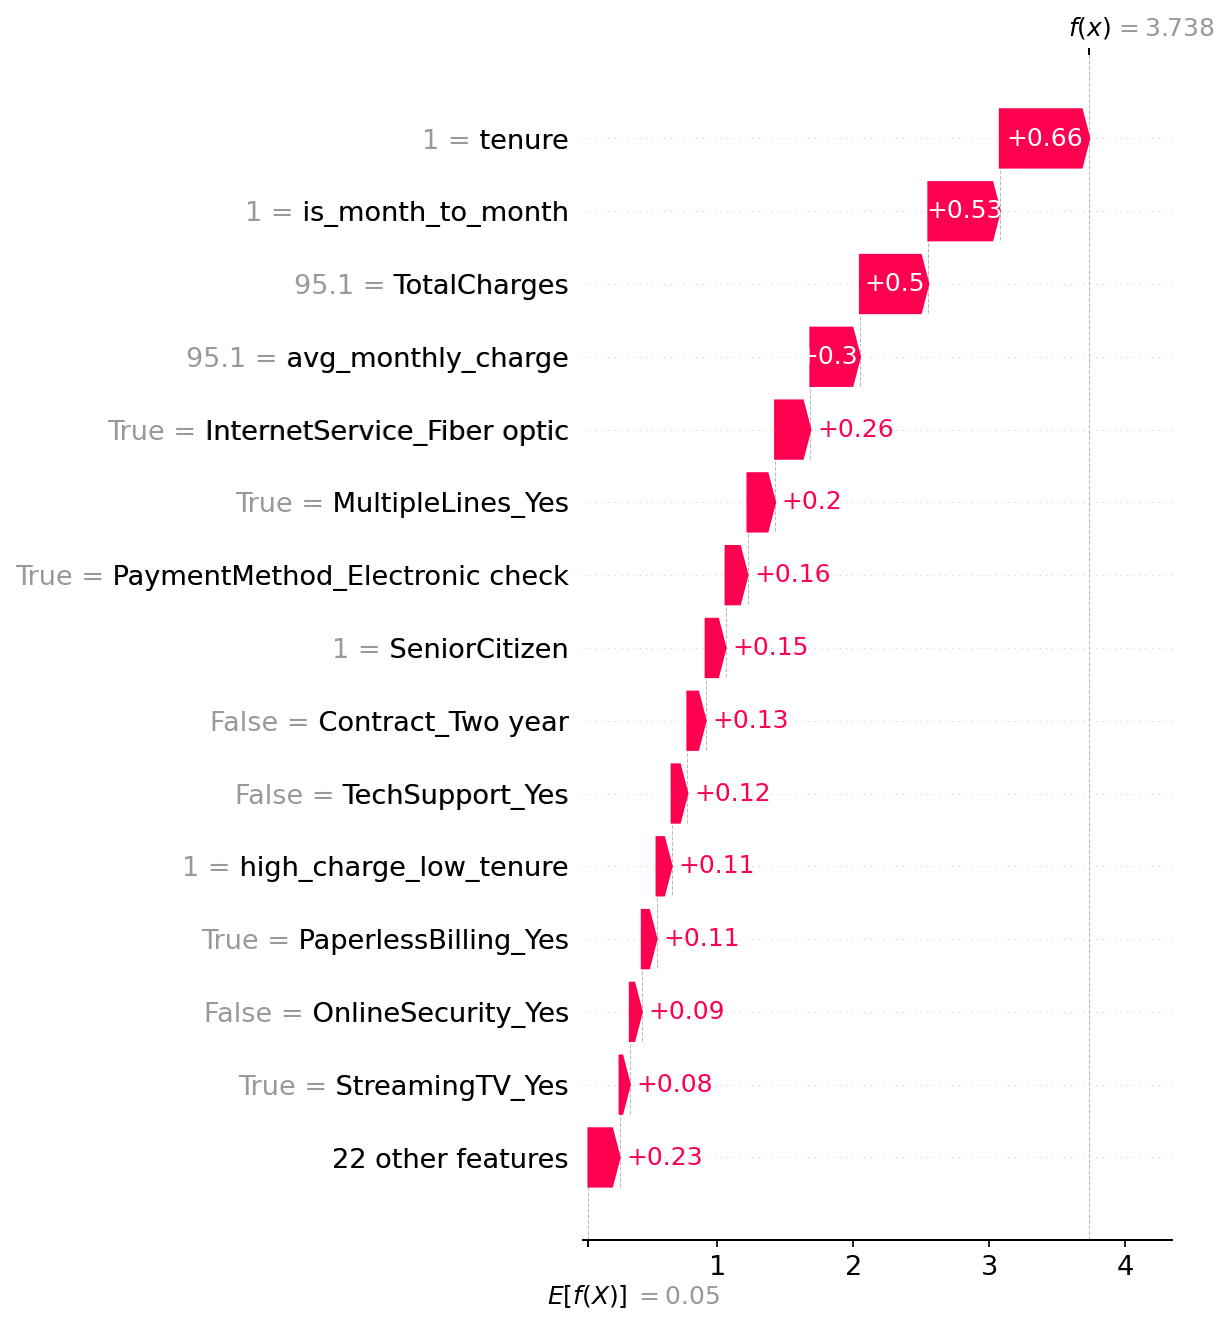

In [7]:
display(Image(filename=str(fig_dir / 'shap_local_explanation.png')))

## 风险分层结果

In [8]:
display(risk_df)

risk_df["risk_level"] = risk_df["risk_level"].astype(str).str.strip()

high_risk_mask = risk_df["risk_level"].str.contains("高", na=False)

if high_risk_mask.any():
    high_risk_row = risk_df.loc[high_risk_mask].iloc[0]
    print("高风险客户数量:", int(high_risk_row["customer_count"]))
    print("高风险客户占比:", f"{float(high_risk_row['ratio_pct']):.2f}%")
else:
    print("未在 risk_segment_summary.csv 中找到高风险记录。")
    print("当前 risk_level 取值:", risk_df["risk_level"].unique().tolist())


,risk_level,customer_count,ratio,ratio_pct
0,低风险,768,0.545067,54.51
1,中风险,315,0.223563,22.36
2,高风险,326,0.231370,23.14


高风险客户数量: 326
高风险客户占比: 23.14%


## 高风险客户样例数据

In [9]:
display(high_risk_df.head(10))

,true_label,pred_label,churn_probability,risk_level
0,0,1,0.942150,高风险
1,0,1,0.838570,高风险
2,0,1,0.743544,高风险
3,1,1,0.879258,高风险
4,0,1,0.831901,高风险
5,1,1,0.895894,高风险
6,1,1,0.888835,高风险
7,1,1,0.843722,高风险
8,0,1,0.721418,高风险
9,1,1,0.903135,高风险


## SHAP 特征驱动策略分析
- `is_month_to_month` 与 `Contract` 相关特征靠前，说明短约客户流失敏感度更高，应优先推动短约转长约。
- `tenure` 影响显著，说明新客稳定性不足，应强化入网前 90 天保活触达。
- `MonthlyCharges`、`avg_monthly_charge`、`TotalCharges` 共同进入 Top，表明价格与价值感知是关键矛盾点，应做分层定价与权益补偿。
- `PaymentMethod_Electronic check` 指向缴费摩擦风险，应推动自动支付迁移降低中断流失。
- `InternetService_Fiber optic` 说明网络体验管理重要，应对高风险光纤客群优先做服务质检与回访。

## 策略文件预览

In [10]:
display(Markdown(strategy_text[:5000]))

# 客户流失预测业务策略建议（SHAP 特征驱动型）

## 1. 模型概况
- 最佳模型名称：xgboost
- 关键指标：
  - accuracy: 0.7566
  - precision: 0.5279
  - recall: 0.7834
  - f1: 0.6308
  - roc_auc: 0.8430
  - pr_auc: 0.6556

说明：本项目核心目标是尽可能识别潜在流失客户，因此在模型选择时优先考虑 `roc_auc`、`pr_auc` 与 `recall` 的综合表现，而不是只看 Accuracy。

## 2. 风险分层结果
- 低风险：768 人（54.51%）
- 中风险：315 人（22.36%）
- 高风险：326 人（23.14%）

业务解释：
- 高风险客户约占四分之一，属于可直接转化为运营清单的重点干预群体。
- 中风险客户适合低成本、自动化策略持续培育，防止滑落到高风险层。

## 3. SHAP 特征驱动型策略映射
下表体现“因为某特征显著影响流失概率，所以制定对应策略”的数据驱动逻辑：

| SHAP关键特征 | 业务含义 | 典型高风险客户表现 | 对应挽留策略 | 预期业务目标 |
|---|---|---|---|---|
| is_month_to_month | 短约客户承诺成本低，流失弹性高 | Month-to-month 客户占比高，续费稳定性差 | 设计“短约转长约”专项：提供 12/24 月合约折扣与迁转礼包 | 提升长期合约占比，降低短约客群流失率 |
| tenure | 在网时长反映关系稳定性，新客更易流失 | tenure 偏低，处于首月/首季敏感期 | 建立新客 90 天保活计划：分阶段权益提醒、专席回访、体验问题闭环 | 提升新客 3 个月留存率 |
| InternetService_Fiber optic | 光纤用户对速度和稳定性预期高，体验波动会放大不满 | 光纤客户投诉或体验波动时流失概率上升 | 对光纤高风险人群优先执行网络质检、故障补偿、服务承诺升级 | 降低光纤用户因体验问题导致的流失 |
| Contract_Two year | 长约通常降低流失倾向，缺少长约绑定风险更高 | 高风险客户中两年合约占比偏低 | 针对高价值中高风险客户推广两年合约+增值服务打包 | 提高客户生命周期价值（LTV）与续约稳定性 |
| TotalCharges | 总消费体现历史价值与服务深度，异常结构提示价值流失风险 | 高消费但留存不稳，历史价值客户存在离网风险 | 对高 TotalCharges 且高风险客户提供“价值守护包”（专属顾问+定向优惠） | 保护高价值客户，减少营收流失 |
| avg_monthly_charge | 平均月消费高说明价格敏感与价值感知之间存在张力 | 账单压力高、成本敏感，易对比竞品 | 价格弹性分层：给出阶梯折扣、同价提速、套餐重构建议 | 降低价格敏感客户流失率 |
| PaymentMethod_Electronic check | 支付方式可能伴随缴费摩擦和中断风险 | Electronic check 客群在高风险中占比较高 | 推动自动扣费迁移（银行卡/信用卡自动支付）并提供迁移激励 | 降低缴费中断导致的被动流失 |
| MonthlyCharges | 当前月费是最直接价格感知信号 | 月费较高且缺少增值服务，性价比感知偏弱 | 执行“高月费价值提升方案”：同价增加权益、推荐组合包、账单透明化 | 提升价格-价值匹配度，减少因价格不满流失 |

## 4. 分层挽留执行方案
### 高风险客户（优先级 P0）
- 人工客服优先回访（48 小时内）
- 定向优惠券 / 套餐折扣（基于月费与在网时长分层）
- 短约转长约激励
- 技术支持与增值服务包推荐

### 中风险客户（优先级 P1）
- 自动化营销触达（短信/APP/邮件）
- 个性化套餐推荐
- 会员权益提醒
- 服务组合捆绑推荐

### 低风险客户（优先级 P2）
- 常规服务维护
- 满意度巡检
- 续约与交叉销售引导

## 5. 落地执行建议与监控
- 每周运行一次流失预测，更新风险清单
- 将 `churn_probability >= 0.7` 的客户自动入池并推送运营团队
- 将 SHAP Top 特征（合同类型、在网时长、月费、支付方式）纳入周报看板
- 建议追踪三类运营 KPI：
  - 高风险客群 30 天挽留率
  - 中风险客群降级到低风险比例
  - 短约转长约转化率
